In [1]:
# STANDIN A0
# Load the data, the split and the shared helpers (parts/00_setup.ipynb). Dropped from the hand-in
# notebook, where the setup cells come first.
%run 00_setup.ipynb

Python 3.13.7, scikit-learn 1.6.1, numpy 2.5.3, pandas 3.0.6
Working directory: /home/steven/Desktop/AI-for-Cybersecurity-Final-Mini-Project
Data folder: /home/steven/Desktop/AI-for-Cybersecurity-Final-Mini-Project/UNSW-NB15
score() and score_proba() ready


Rows with an infinite or missing value: 0
Loaded 447,915 flows x 76 features


Raw rows:                      447,915
Exact duplicates removed:      141,742
Conflicting rows removed:        1,068
Clean rows (all are used):     305,105


Dropped 9 constant columns: Bwd PSH Flags, Fwd URG Flags, Bwd URG Flags, URG Flag Count, CWR Flag Count, ECE Flag Count, Fwd Bytes/Bulk Avg, Fwd Packet/Bulk Avg, Fwd Bulk Rate Avg
67 features: 65 continuous, 2 0/1 columns (Fwd PSH Flags, RST Flag Count)
TUNE_IDX: 36,612 training rows for settings searches
Setup complete: 22 shared names ready in 50 s


In [2]:
# STANDIN B2
# The Part B black box with the settings chosen on validation in B2 (parts/10_baseline_models.ipynb).
# Dropped from the hand-in notebook, where the real B2 cell comes first.
from sklearn.ensemble import HistGradientBoostingClassifier

BOOST_SETTINGS = {"learning_rate": 0.1, "max_leaf_nodes": 31, "random_state": SEED}
def make_boost():
    return HistGradientBoostingClassifier(**BOOST_SETTINGS)

boost = make_boost().fit(X_train, y_train)

<!-- STEP D1 -->
## Part D: global explanation with SHAP

**What SHAP does.** For one flow, SHAP splits the model's output into one contribution per feature:
"`Fwd Seg Size Min` pushed this flow towards *attack* by 2.1, `Bwd Packets/s` pushed it towards *benign*
by 0.4, ...". The contributions add up exactly to the model's output for that flow, starting from a
*base value* (the model's average output). Averaging the size of each feature's contributions over many
flows gives a **global ranking**: which features the model relies on most.

**For gradient boosting the unit is log-odds**, not probability: 0 means 50% attack, +2 about 88%, −2
about 12%. Larger in absolute value means a stronger push. We use `TreeExplainer`, the exact and fast SHAP
method for tree models.

**Which flows.** 1,000 random flows of the **validation** set (seed 42). Part F picks its two features
from this ranking, and choosing anything must not look at the test set.

The feature meanings come from the glossary written in step T4 (`results/tables/T4_feature_glossary.csv`).

In [3]:
# STEP D1
import sys

import matplotlib.pyplot as plt
import shap

sys.path.insert(0, "src")
import xai_tools  # noqa: E402  SHAP/LIME helpers from Lab 3 (src/xai_tools.py)

GLOSSARY = pd.read_csv(TABLES / "T4_feature_glossary.csv", index_col="feature")

EXPLAIN_VAL = X_val.sample(1000, random_state=SEED)          # 1,000 random validation flows
explainer = shap.TreeExplainer(boost)
sv = explainer(EXPLAIN_VAL)
assert sv.values.shape == (1000, len(FEATURES)), sv.values.shape

# Check that the contributions add up: base value + sum of SHAP values = the model's log-odds output.
assert np.allclose(sv.base_values + sv.values.sum(axis=1), boost.decision_function(EXPLAIN_VAL), atol=1e-6)
# The base value is the model's average output in log-odds. It is not the average probability:
# benign flows get very negative log-odds and pull the average far below 0.
print(f"Base value (average model output): {float(np.mean(sv.base_values)):.2f} log-odds")
print(f"The 1,000 flows: {int(y_val.loc[EXPLAIN_VAL.index].sum())} attacks, "
      f"{int((y_val.loc[EXPLAIN_VAL.index] == 0).sum())} benign")

shap_global = (pd.Series(np.abs(sv.values).mean(axis=0), index=FEATURES)
               .sort_values(ascending=False))
top = pd.DataFrame({"mean_abs_shap": shap_global,
                    "share_of_total": shap_global / shap_global.sum()}).head(10)
top["cumulative_share"] = top["share_of_total"].cumsum()
top = top.join(GLOSSARY[["meaning", "direction", "group_proposed"]])
top.index.name = "feature"
top.to_csv(TABLES / "D1_shap_top.csv", float_format="%.4f")
top.style.format({"mean_abs_shap": "{:.3f}", "share_of_total": "{:.1%}", "cumulative_share": "{:.1%}"})

Base value (average model output): -6.73 log-odds
The 1,000 flows: 260 attacks, 740 benign


,mean_abs_shap,share_of_total,cumulative_share,meaning,direction,group_proposed
feature,,,,,,
Fwd Seg Size Min,3.614,42.0%,42.0%,Smallest header size seen in the initiator's packets; depends on the initiator's operating system and TCP options,forward,Free
FWD Init Win Bytes,1.842,21.4%,63.4%,TCP window size in the initiator's first packet: how much data it accepts at once. Set by the initiator's operating system (0 = not TCP or not recorded),forward,Free
Bwd Packets/s,1.113,12.9%,76.4%,How fast the responder sent packets,backward,Fixed
Total Length of Bwd Packet,0.265,3.1%,79.4%,Total payload bytes the responder sent back,backward,Fixed
Packet Length Max,0.183,2.1%,81.6%,"Largest packet payload in the conversation, either direction",both,Fixed
Bwd Packet Length Min,0.170,2.0%,83.5%,Smallest packet payload the responder sent,backward,Fixed
Flow Bytes/s,0.127,1.5%,85.0%,Data rate of the whole conversation (bytes / duration),both,Fixed
Bwd Packet Length Mean,0.095,1.1%,86.1%,Average packet payload the responder sent,backward,Fixed
Packet Length Mean,0.090,1.0%,87.2%,"Average packet payload, both directions together",both,Fixed


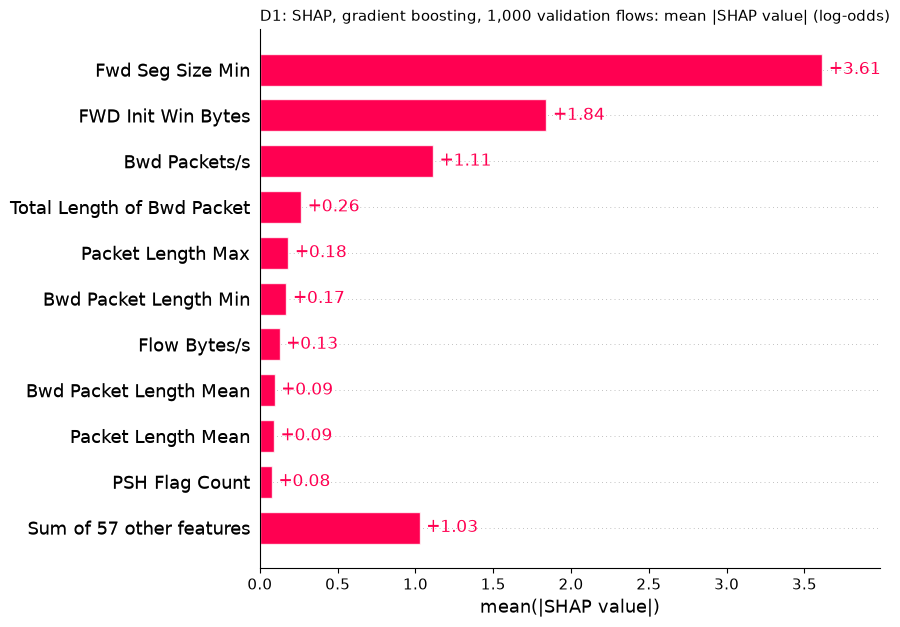

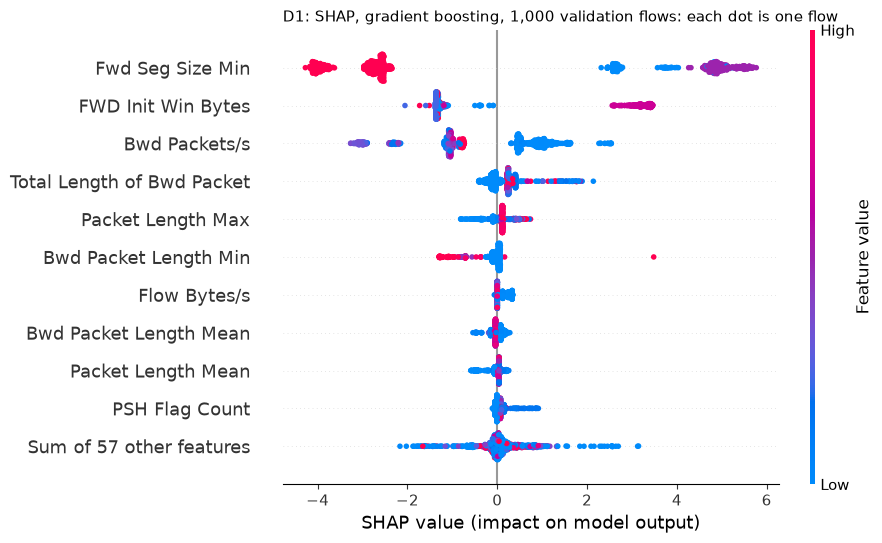

In [4]:
# STEP D1
# Bar plot: average size of each feature's contribution. Beeswarm: one dot per flow, coloured by the
# feature's value (red = high, blue = low); dots to the right push towards "attack".
shap.plots.bar(sv, max_display=11, show=False)
plt.title("D1: SHAP, gradient boosting, 1,000 validation flows: mean |SHAP value| (log-odds)",
          loc="left", fontsize=11)
plt.savefig(FIGURES / "D1_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

shap.plots.beeswarm(sv, max_display=11, show=False)
plt.title("D1: SHAP, gradient boosting, 1,000 validation flows: each dot is one flow", loc="left",
          fontsize=11)
plt.savefig(FIGURES / "D1_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

<!-- STEP D1 -->
### What the global SHAP picture shows

**Three features carry three quarters of the model's reasoning.** `Fwd Seg Size Min` (42% of the total
SHAP weight), `FWD Init Win Bytes` (21%) and `Bwd Packets/s` (13%) together account for 76%; the other
64 features share the rest. (The base value, the model's average output, is −6.7 log-odds; that every
contribution adds up exactly to the model's output is checked in the code.)

**The top two describe the attacker's machine, not the attack.** Both are TCP settings that the operating
system of the initiating computer chooses when it opens a connection. In the training data:

| Value | Training flows | Share that are attacks |
|---|---:|---:|
| `Fwd Seg Size Min` = 20 bytes | 51,301 | 89% |
| `Fwd Seg Size Min` = 32 bytes | 106,150 | 0% |
| `FWD Init Win Bytes` = 16,383 | 50,987 | 90% |
| `FWD Init Win Bytes` = 5,792 | 87,434 | 0% |

95% of all training attacks (45,841 of 48,155) open their connection with a window of exactly 16,383 bytes.
In the beeswarm this shows as two well-separated clouds per feature: one value pushes strongly towards
"attack", the other strongly towards "benign". In UNSW-NB15 all attacks were generated by a few attacker
machines with their own TCP settings, while the normal traffic came from other machines. The model has
learned to **recognise those machines**: a *shortcut* that works on this dataset but says nothing about
what an attack does.

**Do the features make sense to a security person? Only partly.**
- `Fwd Seg Size Min` and `FWD Init Win Bytes`: no, not as evidence of an attack. They are a fingerprint of
  the machine. An attacker using another operating system, or changing two TCP settings on their own
  machine, would no longer look like this, and a normal computer that happens to share these settings
  would look like an attacker. A security person would use them to recognise *known* machines, not
  attacks in general.
- `Bwd Packets/s` (how fast the other side replies), `Total Length of Bwd Packet`, `Packet Length Max`,
  `Bwd Packet Length Min` and `Flow Bytes/s`: yes. They describe the conversation itself: scans and
  floods get few or no replies from the victim, exploits and fuzzing send unusual packet sizes. These are
  the kind of evidence an analyst would look at.

This shortcut is the most important finding of Part D. It explains why the models in Part B are so
accurate, it is what an attacker could fake most cheaply (step E4), and it reappears in Parts F and G.
The optional extra X6 tests how well the model does without the TCP-settings features.